# Minimal-Cost Password-Leak Attacks

This notebook uses Python APIs (no CLI wrappers) of `proverifbatch` to:

- generate and verify scenarios, computing **minimal-cost combinations** that break queries,
- render attack trees for the scenarios that break `no pw leakage`.

In [6]:
import sys

from pathlib import Path
import pandas as pd
from IPython.display import Markdown, SVG, display

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

for module_name in list(sys.modules):
    if module_name == "proverifbatch" or module_name.startswith("proverifbatch."):
        del sys.modules[module_name]

EXAMPLES = [
    PROJECT_ROOT / "examples" / "hashed_passwords.pv",
    PROJECT_ROOT / "examples" / "singularized_passwords.pv",
]

TARGET_QUERY_TAG = "no pw leakage"


In [7]:
# Generate scenarios + run ProVerif via API

from proverifbatch.scenarios import ScenarioPreprocessor

# Generate full scenario combinations so pinned multi-capability scenarios exist.
pre = ScenarioPreprocessor(timeout=300, check_all_scenarios=True)

all_generated = []
file_to_generated = {}
file_to_generated_by_name = {}

for input_file in EXAMPLES:
    input_key = str(input_file)
    generated, out_dir = pre.preprocess(input_key)
    file_to_generated[input_key] = generated
    file_to_generated_by_name[input_key] = {
        scenario.path.name: scenario for scenario in generated
    }
    all_generated.extend(generated)

results = pre.run_proverif(all_generated)
analysis = pre.analyze(results, [str(p) for p in EXAMPLES])

# Build compact table focused on the no pw leakage query
rows = []
for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    combos = by_query.get(TARGET_QUERY_TAG, [])
    for combo in combos:
        caps = sorted(combo["scenarios"])

        cost_items = sorted(combo["costs"].items())
        rows.append({
            "model": model,
            "query": TARGET_QUERY_TAG,
            "minimal_combo": " + ".join(caps) if caps else "base",
            "costs": ", ".join(f"{k}:{v}" for k, v in cost_items) if cost_items else "none",
        })

df_min = pd.DataFrame(rows)
display(df_min.sort_values(["model", "minimal_combo"]).reset_index(drop=True))


Processing: /home/ben/Documents/orange/orangeproject/examples/hashed_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -           10
Intruder at database                             1            -

Total scenarios generated: 4

Processing: /home/ben/Documents/orange/orangeproject/examples/singularized_passwords.pv
Attacker capabilities with costs
------------------------------------------------------------
Capability                                    hack         time
---------------------------------------------------------------
Rainbow table attack                             -          100
Live intrusion at singularization se             1            -
Intruder at database                             1            -
Intruder at singularization databa

,model,query,minimal_combo,costs
0,hashed_passwords,no pw leakage,Intruder at database + Rainbow table attack,"hack:1, time:10"
1,singularized_passwords,no pw leakage,Intruder at database + Intruder at singulariza...,"hack:2, time:100"


## Pareto fronts for `no pw leakage`

We can now compare the budgets for the succeeding attacks on `no pw leakage`:

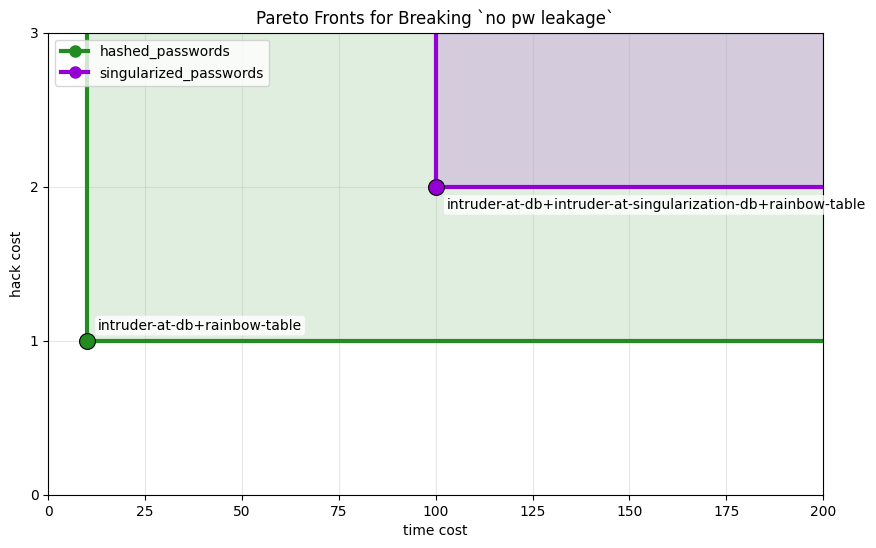

In [8]:
import matplotlib.pyplot as plt

MODEL_STYLES = {
    "hashed_passwords": {"color": "forestgreen", "label": "hashed_passwords"},
    "singularized_passwords": {"color": "darkviolet", "label": "singularized_passwords"},
}

X_MAX = 200
Y_MAX = 3

def format_combo_name(combo_names):
    replacements = {
        "intruder_at_database": "intruder-at-db",
        "rainbow_table_attack": "rainbow-table",
        "intruder_at_singularization_database": "intruder-at-singularization-db",
    }
    ordered = []
    for name in sorted(combo_names):
        normalized = name.strip().lower().replace(" ", "_").replace("-", "_")
        ordered.append(replacements.get(normalized, normalized.replace("_", "-")))
    return "+".join(ordered) if ordered else "base"

pareto_rows = []
for input_file, by_query in analysis.items():
    model = Path(input_file).stem
    for combo in by_query.get(TARGET_QUERY_TAG, []):
        costs = combo.get("costs", {})
        pareto_rows.append({
            "model": model,
            "time": float(costs.get("time", 0)),
            "hack": float(costs.get("hack", 0)),
            "combo": format_combo_name(combo.get("scenarios", [])),
        })

df_pareto = pd.DataFrame(pareto_rows)
if df_pareto.empty:
    raise RuntimeError(f"No breaking scenarios found for {TARGET_QUERY_TAG!r}.")

front_parts = []
for model_name, group in df_pareto.groupby("model", sort=False):
    keep = []
    for idx, row in group.iterrows():
        dominated = (
            (group["time"] <= row["time"])
            & (group["hack"] <= row["hack"])
            & ((group["time"] < row["time"]) | (group["hack"] < row["hack"]))
        ).any()
        if not dominated:
            keep.append(idx)
    front = group.loc[keep].sort_values(["time", "hack"], ascending=[True, False]).reset_index(drop=True)
    front_parts.append(front)

df_front = pd.concat(front_parts, ignore_index=True)

fig, ax = plt.subplots(figsize=(10, 6))
legend_handles = []

for model_name, front in df_front.groupby("model", sort=False):
    style = MODEL_STYLES[model_name]
    color = style["color"]

    boundary_x = [front.iloc[0]["time"], front.iloc[0]["time"]]
    boundary_y = [Y_MAX, front.iloc[0]["hack"]]
    for idx, point in front.iterrows():
        next_time = front.iloc[idx + 1]["time"] if idx + 1 < len(front) else X_MAX
        boundary_x.append(next_time)
        boundary_y.append(point["hack"])
        if idx + 1 < len(front):
            boundary_x.append(next_time)
            boundary_y.append(front.iloc[idx + 1]["hack"])

    polygon_x = [front.iloc[0]["time"], *boundary_x[1:], X_MAX, front.iloc[0]["time"]]
    polygon_y = [front.iloc[0]["hack"], *boundary_y[1:], Y_MAX, Y_MAX]

    ax.fill(polygon_x, polygon_y, color=color, alpha=0.14)
    ax.plot(boundary_x, boundary_y, color=color, linewidth=3, solid_capstyle="round")
    ax.scatter(front["time"], front["hack"], color=color, s=90, zorder=3)

    for idx, point in front.iterrows():
        ax.scatter(
            point["time"],
            point["hack"],
            color=color,
            edgecolor="black",
            linewidth=0.8,
            s=130,
            zorder=4,
        )
        ax.annotate(
            point["combo"],
            (point["time"], point["hack"]),
            xytext=(8, 8 if model_name == "hashed_passwords" else -16),
            textcoords="offset points",
            fontsize=10,
            bbox={"boxstyle": "round,pad=0.2", "facecolor": "white", "alpha": 0.8, "edgecolor": "none"},
        )

    legend_handles.append(
        plt.Line2D([0], [0], color=color, linewidth=3, marker="o", markersize=8, label=style["label"])
    )

ax.set_title("Pareto Fronts for Breaking `no pw leakage`")
ax.set_xlabel("time cost")
ax.set_ylabel("hack cost")
ax.set_xlim(0, X_MAX)
ax.set_ylim(0, Y_MAX)
ax.set_xticks([0, 25, 50, 75, 100, 125, 150, 175, 200])
ax.set_yticks([0, 1, 2, 3])
ax.grid(True, alpha=0.3)
ax.legend(handles=legend_handles, loc="upper left")
plt.show()

## Attack Trees for `no pw leakage`

The interesting scenarios of baseline and singularized protocol are the cheapest ones where there `no pw leakage` query fails. Our scripts can render trees for the attacks that ProVerif finds, and extract which capabilities are used:

### hashed_passwords — rainbow_table_attack+intruder_at_database.pv

- Minimal combo: `Intruder at database, Rainbow table attack`  
- Costs: `{'time': 10, 'hack': 1}`

- Scenario capabilities: `Intruder at database, Rainbow table attack`

Capability nodes shown: 2


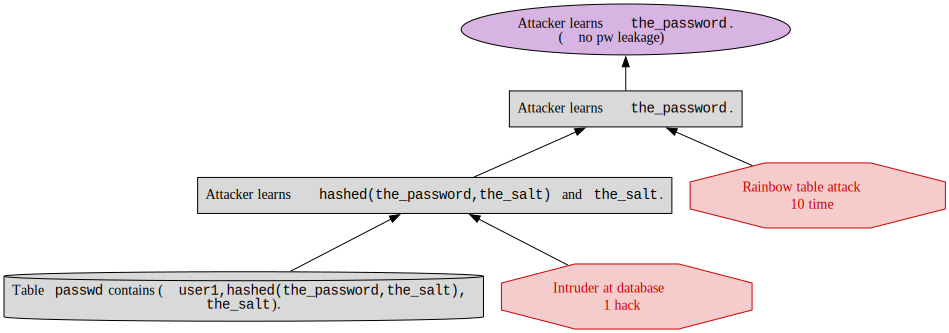

### singularized_passwords — rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv

- Minimal combo: `Intruder at database, Intruder at singularization database, Rainbow table attack`  
- Costs: `{'time': 100, 'hack': 2}`

- Scenario capabilities: `Intruder at database, Intruder at singularization database, Rainbow table attack`

Capability nodes shown: 3


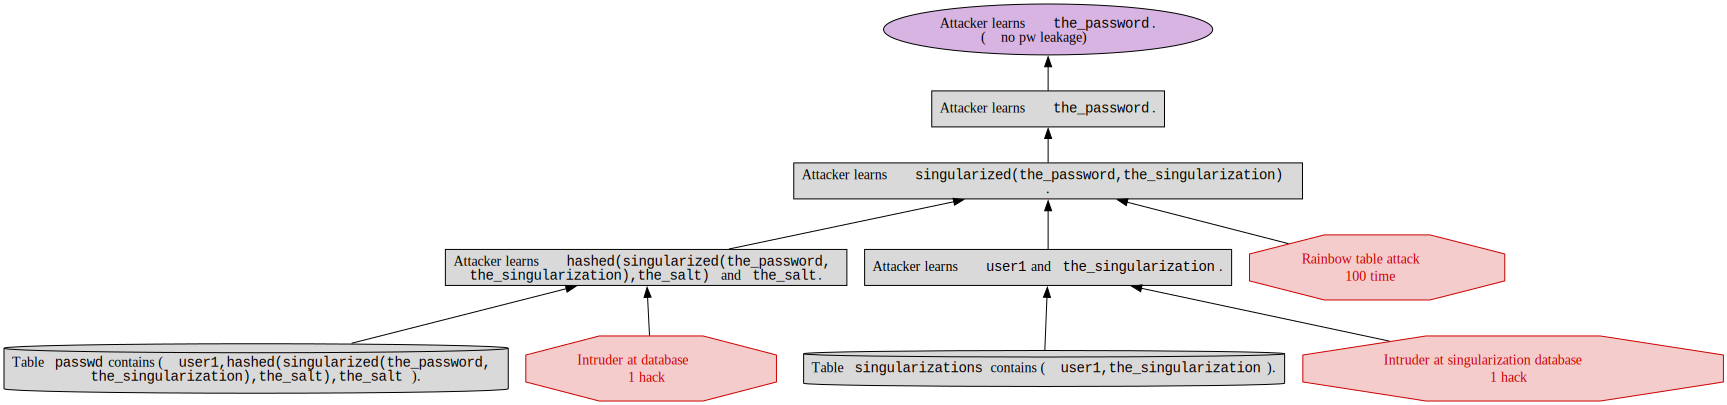

In [9]:

from proverifbatch.attack_tree import AttackTreeExtractor
atk = AttackTreeExtractor(timeout=300)

# Render the pinned scenarios for the no pw leakage query using capability-enhanced trees.
PINNED_SCENARIOS = {
    str(EXAMPLES[0]): "rainbow_table_attack+intruder_at_database.pv",
    str(EXAMPLES[1]): "rainbow_table_attack+intruder_at_database+intruder_at_singularization_database.pv",
}

for input_file in map(str, EXAMPLES):
    scenario = file_to_generated_by_name[input_file][PINNED_SCENARIOS[input_file]]
    model = Path(input_file).stem
    combo_scenarios = sorted(capability.name for capability in scenario.capabilities)

    display(Markdown(f"### {model} — {scenario.path.name}"))
    display(Markdown(f"- Minimal combo: `{', '.join(combo_scenarios) or 'base'}`  \n- Costs: `{scenario.costs}`"))
    display(Markdown(f"- Scenario capabilities: `{', '.join(combo_scenarios) or 'base'}`"))

    build = atk.extract_tree(
        scenario.path,
        query_tag=TARGET_QUERY_TAG,
        scenario_queries=scenario.queries,
        capability_scenarios=file_to_generated[input_file],
        readable_nodes=True,
        show_clause_ids=False,
    )
    if build.tree is None:
        raise RuntimeError("Could not build capability-enhanced tree.")

    capability_node_count = sum(
        1 for node in build.tree.nodes.values() if node.node_type == "capability"
    )
    if capability_node_count == 0:
        print("No capability-specific clauses could be attributed inside this derivation tree.")
    else:
        print(f"Capability nodes shown: {capability_node_count}")

    dot = build.tree.to_graphviz()
    try:
        import graphviz
        src = graphviz.Source(dot, format="svg")
        svg = src.pipe(format="svg").decode("utf-8")
        display(SVG(svg))
    except Exception:
        # Inline SVG rendering unavailable. Showing DOT snippet:"
        print("\n".join(dot.splitlines()[:20]))